# Using the VanquishNeo Method Parser

## Imports

### External Packages

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

### Internal Packages

In [2]:
%load_ext autoreload
%autoreload 2

# Add the source path to Python path
src_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

## Setting Base Path

In [ ]:
source = 'base'

In [ ]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Loading LC Methods

### Making LC Method Collection

#### Making collection object instance

In [48]:
lccollection = VNeoMethodCollection()

#### Adding in VNeo methods from a folder

In [49]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/data/methods/LC/Trap')

#### Using collection functions

In [50]:
lccollection.methods.keys()

dict_keys(['20m150nlML26mV4A15TrapNS5', '20m150nlML26mV5A15TrapNS5', '20m150nlML26mV7A15TrapNS5', 'ML25p5FR150V9A15TrapNS5', '26m150nlML36mA15TrapNS5', '26m150nlML32mV3A15TrapNS5', '26m150nlML36mV2A15TrapNS5', 'ML25p5FR200V9A15TrapNS5', '14m150nlML20mV8A15TrapNS5', '17m150nlML23p5mV6A15TrapNS5'])

##### Comparing Gradients

In [51]:
lccollection.methods['14m150nlML20mV8A15TrapNS5'].gradient

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Neo.PumpModule.Pump.StartColumnWash,length [min]
0,0.0,0.75,2.0,5,NaN,0.0
1,2.0,0.75,17.5,5,NaN,2.0
2,2.1,0.15,21.5,5,NaN,0.1
3,3.1,0.15,25.0,5,NaN,1.0
4,8.1,0.15,40.0,5,NaN,5.0
5,14.1,0.15,40.0,5,1.0,6.0
6,15.1,0.15,95.0,5,NaN,1.0
7,17.1,0.15,95.0,5,NaN,2.0
8,18.1,1.00,50.0,5,NaN,1.0
9,20.0,1.00,50.0,5,NaN,1.9


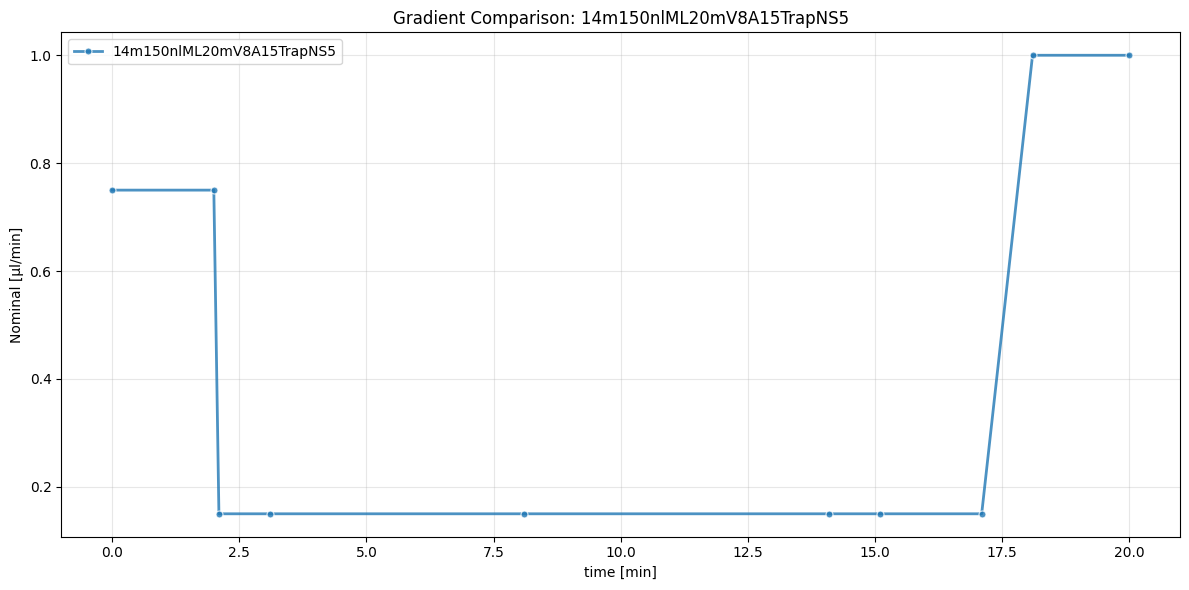

In [12]:
lccollection.plot_gradients(['14m150nlML20mV8A15TrapNS5'],
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
);

## Methods Section

### Examples

Peptides were introduced into the {mass_spec} mass spectrometer using a two-step linear gradient. For organellar IP samples, 3–27% buffer B (0.1% (v/v) formic acid in 80% (v/v) acetonitrile) for 52.5 min followed by 27-40% buffer B for 14.5 min. For N/O/C and WCE samples, 3–27% buffer B for 105 min followed by 27-40% buffer B for 15 min. Both operated with a flow rate of 300 nL/min. Column temperature was maintained at 50°C throughout the procedure.

DOI: 10.1016/j.cell.2024.11.028

pMHC were resuspended in 12 μL of 0.1% formic acid, and 4 μL per injection was introduced into the Fusion Lumos mass spectrometer (Tune application 3.3.2782.32) using a two-step linear gradient with 4–25% buffer B (0.1% (v/v) formic acid in acetonitrile) for 80 min followed by 25–45% buffer B for 10 min. 

https://pubs.acs.org/doi/10.1021/acs.jproteome.0c00464

he peptides were separated on an analytical column 20 cm × 75 μm of C18 TPP beads (1.8 μm, 20 nm, Waters, Milford, MA) that was heated to 60 °C. Separation was achieved through applying an active gradient from 7 to 27% ACN in 0.1% formic acid over 170 min at 200 nl/min. The active gradient was followed by a 10-min 27–97% ACN wash step. 

https://link.springer.com/article/10.1186/s13059-018-1547-5#Sec8

Each TMT labeled set of samples was submitted for single LC-MS/MS experiment that was performed on a LTQ Orbitrap Elite (Thermo Fisher) equipped with a Waters (Milford, MA) NanoAcquity HPLC pump. Peptides were first trapped and washed onto a 5 cm × 150 μm inner diameter microcapillary trapping column packed with C18 Reprosil resin (5 μm, 10 nm, Dr. Maisch GmbH, Germany). The peptides were separated on an analytical column 20 cm × 75 μm of C18 TPP beads (1.8 μm, 20 nm, Waters, Milford, MA) that was heated to 60 °C. Separation was achieved through applying an active gradient from 7 to 27% ACN in 0.1% formic acid over 170 min at 200 nl/min. The active gradient was followed by a 10-min 27–97% ACN wash step.

https://link.springer.com/article/10.1186/s13059-018-1547-5#Sec8

In [40]:
gradient = lccollection.methods['18p6m200nlv34'].gradient

In [51]:
lcmeth = lccollection.methods['18p6m200nlv34']

In [ ]:
col_diam = lcmeth.params['Neo.SystemControllerModule.SeparationColumn1.Diameter [µm]']
col_length = lcmeth.params['Neo.SystemControllerModule.SeparationColumn1.Length [cm]']

'15.0'

In [ ]:
trap_diam = lcmeth.params['Neo.SystemControllerModule.TrapColumn1.Diameter [µm]']
trap_length = lcmeth.params['Neo.SystemControllerModule.TrapColumn1.Length [cm]']
trap_direction = lcmeth.params['Neo.SamplerModule.Sampler.TrapColumnFlushDirection']

start_col_wash = lcmeth.gradient[lcmeth.gradient['Neo.PumpModule.Pump.StartColumnWash'] == True]['time [min]']

In [44]:
lccollection.methods['18p6m200nlv34'].params['Neo.SystemControllerModule.InjectionWorkflow']

'DirectInjection'

Peptides were separated on a [column dimensions, e.g., 25 cm × 75 µm inner diameter] reversed-phase analytical column packed with [stationary phase, e.g., 1.9 µm C18 particles] (manufacturer) maintained at [column temperature, e.g., 50°C]. Samples were loaded onto a [trap column description, e.g., 2 cm × 100 µm µm inner diameter Acclaim PepMap trap column] at [loading flow rate, e.g., 5 µL/min] in [loading solvent, e.g., 0.1% formic acid in water] for [loading time, e.g., 5 min].
Peptides were eluted using a binary solvent system consisting of solvent A ([e.g., 0.1% formic acid in water]) and solvent B ([e.g., 0.1% formic acid in 80% acetonitrile]) at a flow rate of [e.g., 300 nL/min]. The gradient proceeded as follows: [e.g., 2–8% B over 5 min, 8–35% B over 90 min, 35–50% B over 10 min, 50–95% B over 2 min, held at 95% B for 5 min], followed by re-equilibration at [starting % B] for [re-equilibration time] prior to the next injection. Total run time was [X min] per sample.
[If relevant:] An in-line Vanquish Neo / nanoElute / EASY-nLC 1200 system (Thermo Fisher Scientific / Bruker) was used for all chromatographic separations.

For Rapid CSI columns, peptides were separated using a gradient of 1–3% B (0–1 min) followed by 3–35% B (1–14 min) at a flow rate of 0.25 µL/min. For Ultimate CSI columns, the gradient was 1–3% B (0–1 min) followed by 3–35% B (1–37 min) at 0.4 µL/min. 

In [ ]:
column = f'Peptides were separated on a [column dimensions, e.g., 25 cm × 75 µm inner diameter] reversed-phase analytical column packed with [stationary phase, e.g., 1.9 µm C18 particles] (manufacturer) maintained at [column temperature, e.g., 50°C]. Samples were loaded onto a [trap column description, e.g., 2 cm × 100 µm µm inner diameter Acclaim PepMap trap column] at [loading flow rate, e.g., 5 µL/min] in [loading solvent, e.g., 0.1% formic acid in water] for [loading time, e.g., 5 min].'

Peptides were eluted using a binary solvent system consisting of solvent A ([e.g., 0.1% formic acid in water]) and solvent B ([e.g., 0.1% formic acid in 80% acetonitrile]) at a flow rate of [e.g., 300 nL/min]. The gradient proceeded as follows: [e.g., 2–8% B over 5 min, 8–35% B over 90 min, 35–50% B over 10 min, 50–95% B over 2 min, held at 95% B for 5 min], followed by re-equilibration at [starting % B] for [re-equilibration time] prior to the next injection. Total run time was [X min] per sample.
[If relevant:] An in-line Vanquish Neo / nanoElute / EASY-nLC 1200 system (Thermo Fisher Scientific / Bruker) was used for all chromatographic separations.'

1. direct/trap 
    * direct inject:
        * The LC was plumbed for direct injection.
            * Samples were loaded at [loading pressure] bar.
    * trap
        * The LC was plumbed for trap-and-elute  and employed in a reverse-flush configuration
        * Peptide were loaded at 
        * trap unheated at ambient temp
2. Analytical column dimension
3. loading param
4. gradient
    * flow rate change
    * %B 
    * linear
    * time
5. LC

For trap-elute workflows, a NanoShield™ C18 trap column (5 cm × 100 µm, 3 µm C18 particles, IonOpticks) and a competitor C18 trap cartridge (5 mm × 300 µm, 5 µm C18 particles) were employed in a reverse-flush configuration. All traps were unheated over the valve at ambient temperatures. The mobile phases consisted of 0.1% formic acid (FA) in LC–MS-grade water (buffer A) and 0.1% FA in 99.9% acetonitrile (buffer B). 

In [41]:
gradient

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,length [min]
0,0.0,0.65,2.0,5,0.0
1,0.9,0.65,10.0,5,0.9
2,1.0,0.65,13.0,5,0.1
3,1.1,0.20,13.0,5,0.1
4,8.1,0.20,30.0,5,7.0
5,11.6,0.20,45.0,5,3.5
6,13.6,0.20,95.0,5,2.0
7,15.6,0.20,95.0,5,2.0
8,16.6,1.00,95.0,5,1.0
9,18.6,1.00,95.0,5,2.0


In [ ]:
for i, row in enumerate(gradient):
    if i < len(gradient) - 1:
        start_flow = row['Neo.PumpModule.Pump.Flow.Nominal [µl/min]']
        end_flow = gradient.iloc[i + 1]['Neo.PumpModule.Pump.Flow.Nominal [µl/min]']

        start_b = row['Neo.PumpModule.Pump.%B.Value [%]']
        end_b = gradient.iloc[i + 1]['Neo.PumpModule.Pump.%B.Value [%]']
        step_length = gradient.iloc[i + 1]['length [min]']

        f'{start_b}–{end_b}% B over {step_length} min at '

In [ ]:
Liquid Chromatography
Peptides were separated on a [column dimensions, e.g., 25 cm × 75 µm inner diameter] reversed-phase analytical column packed with [stationary phase, e.g., 1.9 µm C18 particles] (manufacturer) maintained at [column temperature, e.g., 50°C]. Samples were loaded onto a [trap column description, e.g., 2 cm × 100 µm µm inner diameter Acclaim PepMap trap column] at [loading flow rate, e.g., 5 µL/min] in [loading solvent, e.g., 0.1% formic acid in water] for [loading time, e.g., 5 min].
Peptides were eluted using a binary solvent system consisting of solvent A ([e.g., 0.1% formic acid in water]) and solvent B ([e.g., 0.1% formic acid in 80% acetonitrile]) at a flow rate of [e.g., 300 nL/min]. The gradient proceeded as follows: [e.g., 2–8% B over 5 min, 8–35% B over 90 min, 35–50% B over 10 min, 50–95% B over 2 min, held at 95% B for 5 min], followed by re-equilibration at [starting % B] for [re-equilibration time] prior to the next injection. Total run time was [X min] per sample.
[If relevant:] An in-line Vanquish Neo / nanoElute / EASY-nLC 1200 system (Thermo Fisher Scientific / Bruker) was used for all chromatographic separations.